In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Inlezen van de data
df = pd.read_excel('AmesHousing.xlsx', sheet_name='AmesHousing')

In [22]:
def run_clustering_experiment(df, num_features, cat_features, n_clusters, **kwargs):
    # 1. Selecteer data
    df_sub = df[num_features + cat_features].copy()
    
    # 2. One-hot encoding
    if cat_features:
        df_final = pd.get_dummies(df_sub, columns=cat_features)
    else:
        df_final = df_sub
        
    # 3. Schalen
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(df_final)
    
    # 4. K-Means configuratie (vermijdt dubbele argumenten)
    kmeans_params = {
        'n_clusters': n_clusters,
        'random_state': 42,
        'n_init': 'auto'  # Standaardwaarde
    }
    kmeans_params.update(kwargs) # Jouw keuzes uit help() overschrijven de standaard
    
    model = KMeans(**kmeans_params)
    cluster_labels = model.fit_predict(data_scaled)
    
    # 5. Evaluatie
    inertia = model.inertia_
    sil_score = silhouette_score(data_scaled, cluster_labels)
    
    print(f"--- Experiment: k={n_clusters} | Features: {num_features + cat_features} ---")
    print(f"Inertia: {inertia:.2f}")
    print(f"Silhouette Score: {sil_score:.4f}")
    
    return model, cluster_labels, df_final

In [6]:
# Model 1
model1, labels1, scaled_data1 = run_clustering_experiment(
    df, 
    num_features=['Gr Liv Area', 'Overall Qual'], 
    cat_features=['Neighborhood'], 
    n_clusters=5,
    max_iter=300
)

df['Cluster_M1'] = labels1
print(df[['Gr Liv Area', 'Overall Qual', 'Neighborhood', 'Cluster_M1']].head())

--- Resultaten voor k=5 ---
Inertia: 74581.26
Silhouette Score: 0.1281
   Gr Liv Area  Overall Qual Neighborhood  Cluster_M1
0         1656             6        NAmes           3
1          896             5        NAmes           3
2         1329             6        NAmes           3
3         2110             7        NAmes           3
4         1629             5      Gilbert           0


In [ ]:
# Model 2
model2, labels2, scaled_data2 = run_clustering_experiment(
    df, 
    num_features=['Year Built', 'Full Bath'], 
    cat_features=['House Style'], 
    n_clusters=4,
    init='random'
)

df['Cluster_M2'] = labels2

--- Resultaten voor k=4 ---
Inertia: 16969.99
Silhouette Score: 0.5105


In [23]:
# Model 3
# 'Total Bsmt SF' kan een lege waarde bevatten. Vul deze lege waarden met 0 voordat je gaat clusteren, omdat een lege waarde in dit geval waarschijnlijk betekent dat er geen kelder is.
df = df.fillna({'Total Bsmt SF': 0})

model3, labels3, data3 = run_clustering_experiment(
    df, 
    num_features=['Lot Area', 'Total Bsmt SF'], 
    cat_features=['Garage'], 
    n_clusters=3,
    init="random",
    n_init=20
)

--- Experiment: k=3 | Features: ['Lot Area', 'Total Bsmt SF', 'Garage'] ---
Inertia: 4055.41
Silhouette Score: 0.4884


In [24]:
# Model 4
model4, labels4, data4 = run_clustering_experiment(
    df, 
    num_features=['Full Bath', 'Bedroom AbvGr'], 
    cat_features=['House Style'], 
    n_clusters=4,
    max_iter=500
)

--- Experiment: k=4 | Features: ['Full Bath', 'Bedroom AbvGr', 'House Style'] ---
Inertia: 17923.58
Silhouette Score: 0.4312


In [33]:
# Model 5
model5, labels5, data5 = run_clustering_experiment(
    df, 
    num_features=['SalePrice', 'Overall Qual'], 
    cat_features=['Garage'], 
    n_clusters=4,
    algorithm='elkan'
)

--- Experiment: k=4 | Features: ['SalePrice', 'Overall Qual', 'Garage'] ---
Inertia: 1556.23
Silhouette Score: 0.4971


In [ ]:
# Model 6
model_6, labels6, data6 = run_clustering_experiment(
    df, 
    num_features=['Full Bath', 'Bedroom AbvGr'], 
    cat_features=[], 
    n_clusters=4,
    algorithm='elkan'
)

--- Experiment: k=4 | Features: ['Full Bath', 'Bedroom AbvGr'] ---
Inertia: 1137.78
Silhouette Score: 0.7363


In [ ]:
# Model 7
model7, labels7, data7 = run_clustering_experiment(
    df, 
    num_features=['Full Bath'], 
    cat_features=['Garage'], 
    n_clusters=5,
    init='k-means++'
)

--- Experiment: k=5 | Features: ['Full Bath', 'Garage'] ---
Inertia: 63.26
Silhouette Score: 0.9901


c:\Users\bramp\Documents\HBO-ICT-VT\Semester 4\DEAI_Portfolio\.venv\Lib\site-packages\sklearn\base.py:1336: ConvergenceWarning: Number of distinct clusters (9) found smaller than n_clusters (10). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


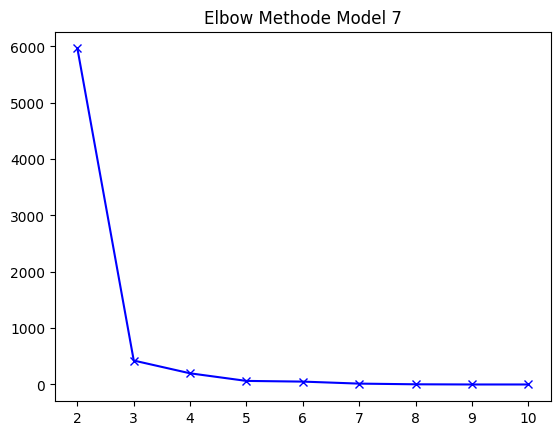

In [37]:
# Gebruik de data van model 7
scaler = StandardScaler()
data7_scaled = scaler.fit_transform(pd.get_dummies(df[['Full Bath', 'Garage']], columns=['Garage']))

inertias = []
K_range = range(2, 11)

for k in K_range:
    m = KMeans(n_clusters=k, random_state=42, n_init='auto')
    m.fit(data7_scaled)
    inertias.append(m.inertia_)

plt.plot(K_range, inertias, 'bx-')
plt.title('Elbow Methode Model 7')
plt.show()